# Optimal Clustering Analysis

In [3]:
import os, sys
import polars as pl
import numpy as np
from db_robust_clust.plots import clustering_MDS_plot_one_method
from sklearn.manifold import MDS
import joblib
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

pl.Config.set_fmt_str_lengths(5000)

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')
sys.path.append(project_path)

from src.utils.clustering_analysis_utils import (
    plot_quant_comparison,
    plot_cat_comparison,
    get_medoid_and_knn_by_cluster
)

#############################################################################################################################

results_dir = os.path.join(project_path, 'data', 'clustering_analysis_results')
models_dir = os.path.join(project_path, 'models')
optimal_clust_model_path = os.path.join(models_dir, 'optimal_clust_model.joblib')
processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
os.makedirs(results_dir, exist_ok=True)

#############################################################################################################################

processed_data = pl.read_parquet(processed_data_path)
clust_object = joblib.load(optimal_clust_model_path)
clust_labels = clust_object.labels_
processed_data = processed_data.with_columns(
    pl.lit(clust_labels).cast(pl.String).alias('clust_label')
)

#############################################################################################################################

QUANT_COMPARISON_COLS = [
    'political_stance_score', 
    'argument_quality_score', 
    'sentiment_score',
    #########################
    'post_score',
    'post_upvote_ratio',
    'post_num_comments',
    'comment_score'
]

CAT_COMPARISON_COLS = [
    'discourse_tone_score_label', 
    'dominant_frame_score_label', 
    'argument_quality_score_label', 
    'sentiment_score_label', 
    'political_stance_score_label',
    #########################
    'post_subreddit'
]

CAT_COMPARISON_ORDER = {
    'political_stance_score_label': [
        'Strongly Pro-Palestine',
        'Leaning Pro-Palestine',
        'Neutral / Balanced',
        'Leaning Pro-Israel',
        'Strongly Pro-Israel'
    ],
    'sentiment_score_label': [
        'Very Negative',
        'Moderately Negative',
        'Mildly Negative',
        'Neutral',
        'Mildly Positive',
        'Moderately Positive',
        'Very Positive',
    ],
    'argument_quality_score_label': [
        'Spam / Non-Argument',
        'Pure Reaction', 
        'Bare Opinion',
        'Justified Opinion',
        'Reasoned Argument',
        'Sophisticated Discourse'
    ]
}

KNN_K_TEXTS = 10
KNN_K_PLOTS = 50 

#############################################################################################################################

In [ ]:
clust_labels = clust_object.labels_
D, D1, D2, D3 = clust_object.dist_output
sample_idx = clust_object.sample_idx

n_reduced = 2000

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=123) 

X_mds = mds.fit_transform(D[:n_reduced, :n_reduced])


plot_file_name = 'optimal_clust_mds_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

clustering_MDS_plot_one_method(X_mds=X_mds, 
                            y_pred=clust_labels[sample_idx[:n_reduced]], 
                            y_true=None, title="MDS visualization of clustering results", 
                            accuracy=None, time=None, 
                            figsize=(8,7), bbox_to_anchor=(1,1), 
                            title_size=13, title_weight='bold', 
                            points_size=45, title_height=1, legend_size=9,
                            save=True, file_name=plot_save_path, format='png'
)

c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


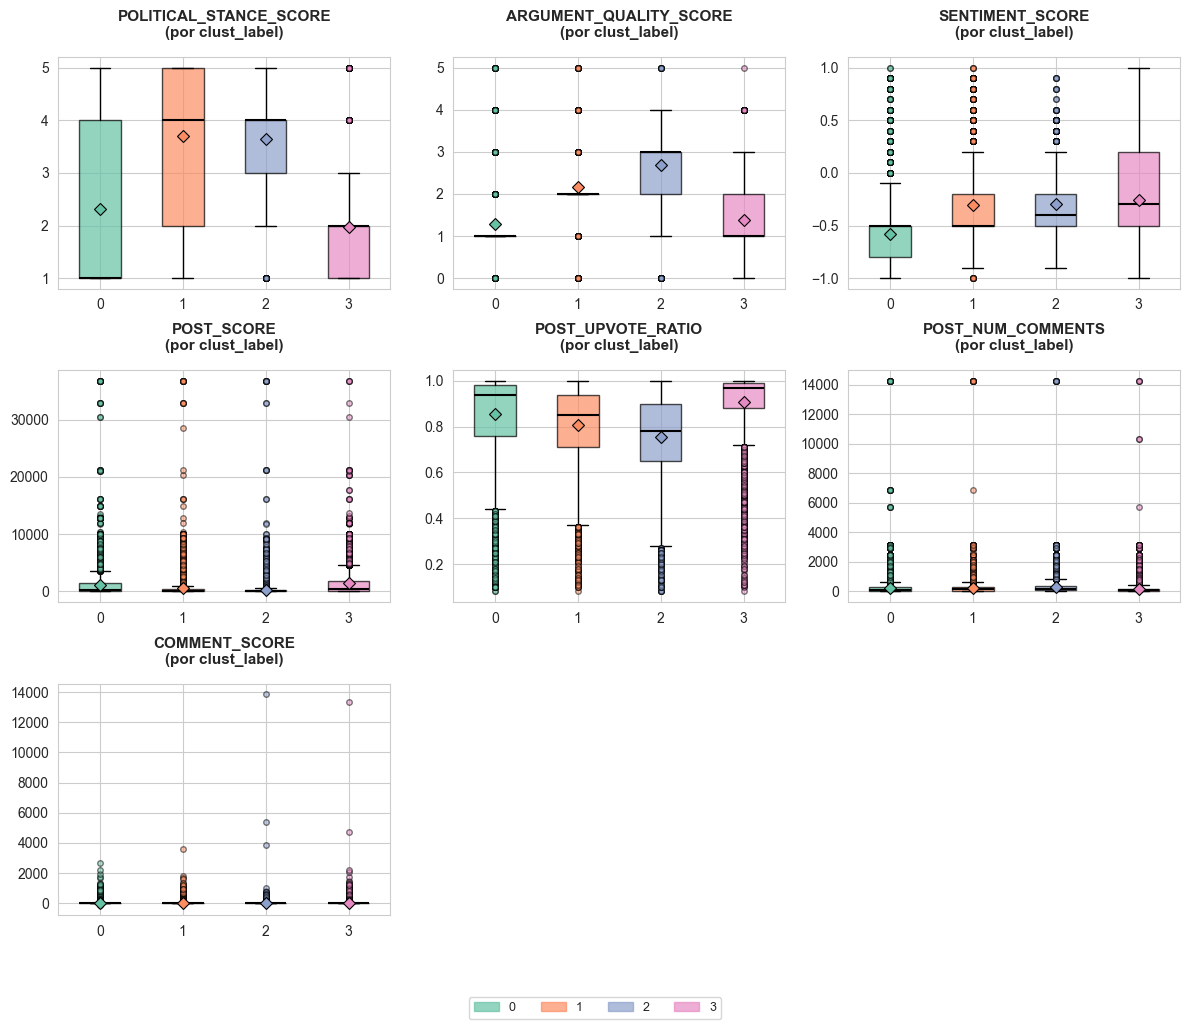

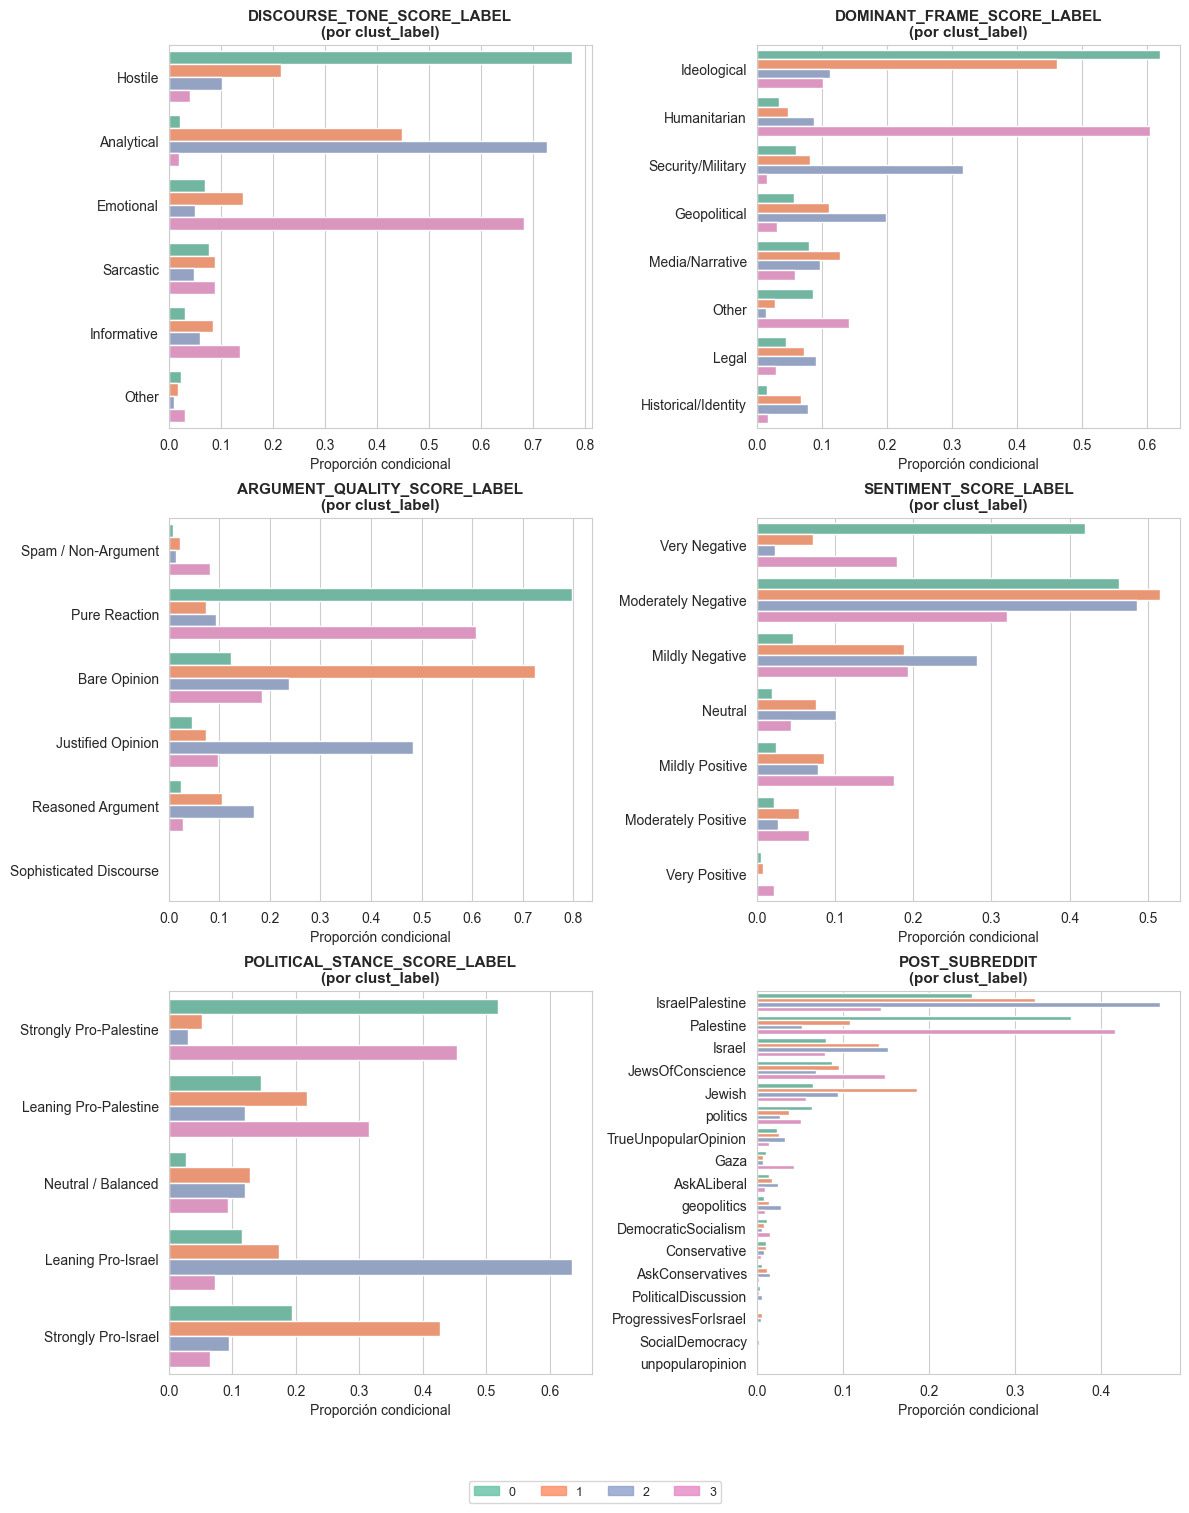

In [ ]:
##################################################################################################

plot_file_name = 'optimal_clust_quant_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_comparison(
    figsize=(12, 10),
    df=processed_data,
    comparisons=[
        [col] for col in QUANT_COMPARISON_COLS
    ],
    group_by="clust_label",
    showfliers=True,
    title='',
    labelbottom=True,
    xlabel_rotation=0,
    bbox_to_anchor=(0.5, -0.03),
    save_path = plot_save_path
    
)

##################################################################################################

plot_file_name = 'optimal_clust_cat_comparison_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_cat_comparison(
    df=processed_data, 
    comparisons=[
        [col] for col in CAT_COMPARISON_COLS 
    ], 
    title="",
    bbox_to_anchor=(0.5,-0.01),
    group_by="clust_label",
    max_cols=2,
    x_rotation=0,
    orientation='h',
    order=CAT_COMPARISON_ORDER,
    save_path = plot_save_path
)

##################################################################################################

Filtrando dataset mediante índices de medoids y KNN...
Lematizando exclusivamente los comentarios filtrados...
Agrupando comentarios por cluster...
Generando Gráfico de Barras SOTA...


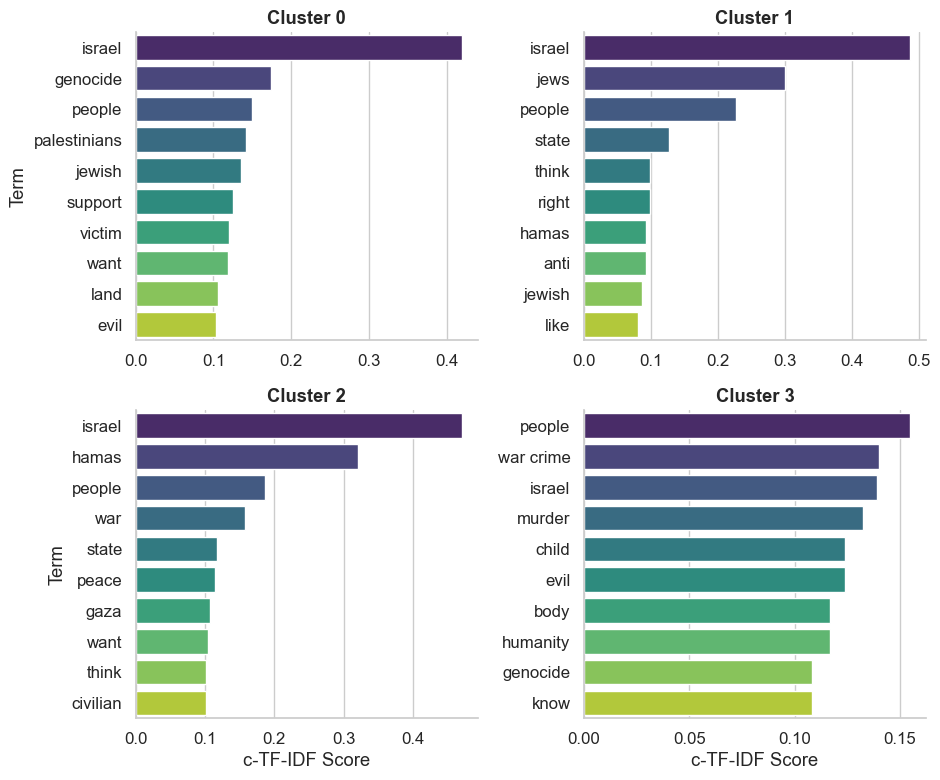

Generando Nubes de Palabras basadas en pesos c-TF-IDF...


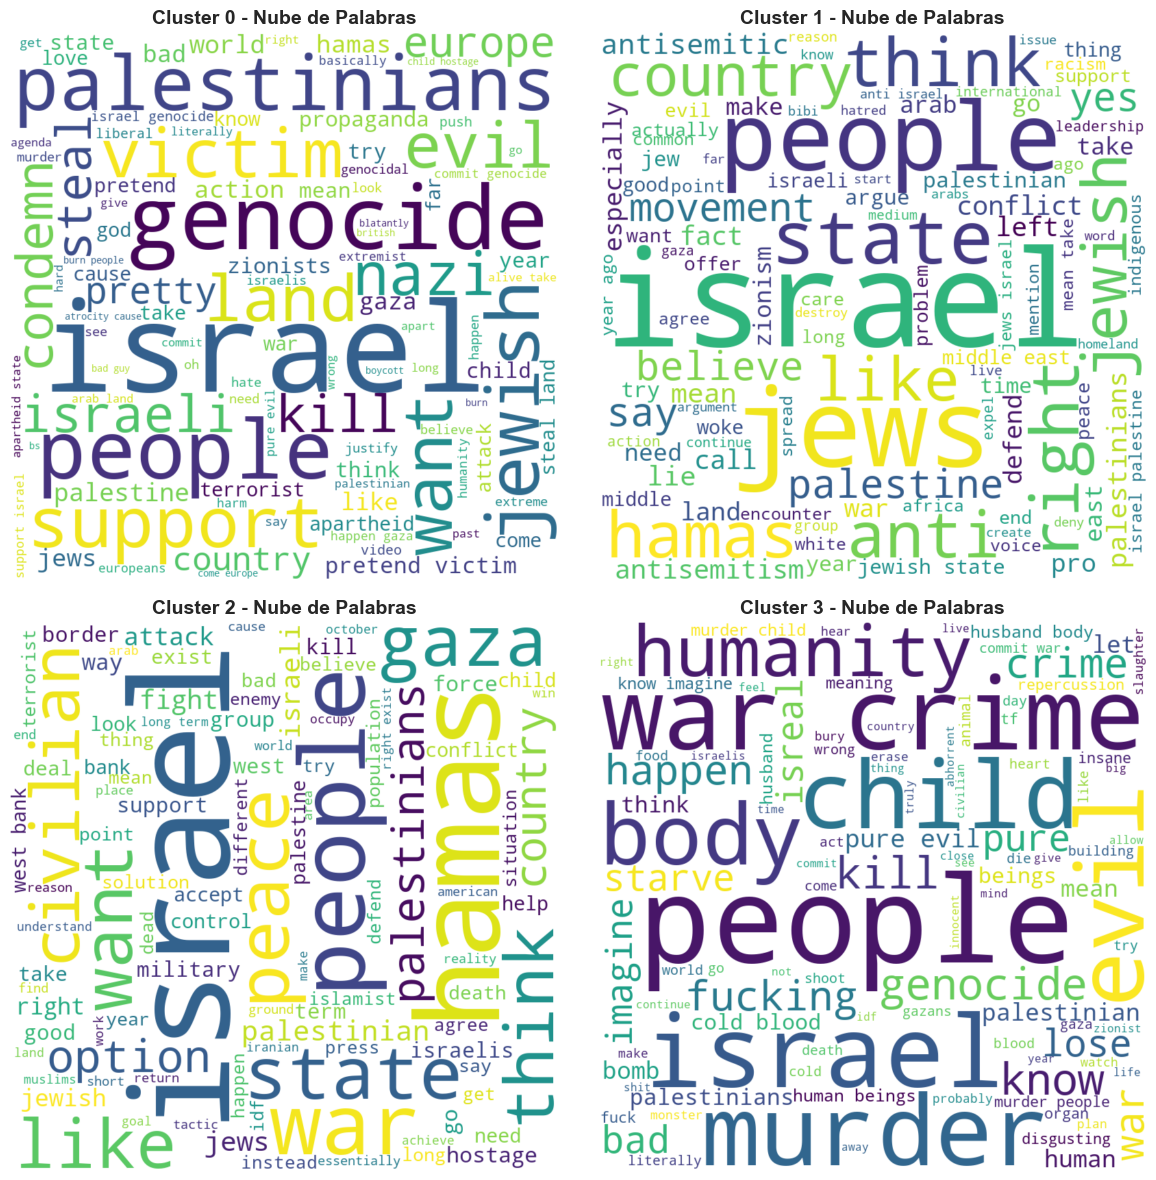

In [ ]:
medoid_and_knn_by_cluster = get_medoid_and_knn_by_cluster(clust_object, dist_matrix=D, knn_k=KNN_K_PLOTS)


# Extraemos todos los índices en una lista plana
all_target_indices = [idx for indices in medoid_and_knn_by_cluster.values() for idx in indices]

# Cargar modelo NLP
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"]) 

# ==========================================
# FASE 1: FILTRADO Y PREPROCESAMIENTO
# ==========================================
print("Filtrando dataset mediante índices de medoids y KNN...")

# Añadimos un índice de fila para poder filtrar exactamente por las posiciones del diccionario
df = processed_data.with_row_index("row_idx").filter(pl.col("row_idx").is_in(all_target_indices))

# Eliminamos nulos específicamente de la columna de comentarios
df = df.with_columns(pl.col("comment_body").fill_null("").alias("target_text"))

def clean_text_batch(texts):
    for doc in nlp.pipe(texts, batch_size=1000):
        # Excluimos stopwords, puntuación y números
        tokens = [token.lemma_.lower() for token in doc if not token.is_stop and token.is_alpha]
        yield " ".join(tokens)

print("Lematizando exclusivamente los comentarios filtrados...")
raw_comments = df["target_text"].to_list()
df = df.with_columns(pl.Series(name="cleaned_comment", values=list(clean_text_batch(raw_comments))))

# ==========================================
# FASE 2: C-TF-IDF (SIN INFLACIÓN DE CONTEXTO)
# ==========================================
print("Agrupando comentarios por cluster...")
cluster_df = (
    df.group_by("clust_label")
    .agg(pl.col("cleaned_comment").str.join(" ")) 
    .sort("clust_label")
)

cluster_labels = cluster_df["clust_label"].to_list()
cluster_corpus = cluster_df["cleaned_comment"].to_list()

# Aplicamos TF-IDF sobre el corpus puro de comentarios
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(cluster_corpus)
feature_names = vectorizer.get_feature_names_out()

# ==========================================
# FASE 3: PREPARACIÓN DE DATOS (BAR CHART)
# ==========================================
top_n = 10
plot_data = []
# Guardaremos los diccionarios de frecuencias para las nubes de palabras
cluster_term_frequencies = {} 

for i, label in enumerate(cluster_labels):
    row = tfidf_matrix.getrow(i).toarray()[0]
    
    # Extraer Top N para el gráfico de barras
    top_indices = row.argsort()[-top_n:][::-1]
    for idx in top_indices:
        plot_data.append({
            "Cluster": label,
            "Term": feature_names[idx],
            "c-TF-IDF Score": row[idx]
        })
        
    # Extraer todas las palabras con score > 0 para una nube de palabras precisa
    cluster_term_frequencies[label] = {
        feature_names[idx]: row[idx] for idx in np.where(row > 0)[0]
    }

df_plot = pl.DataFrame(plot_data)

# ==========================================
# FASE 4: VISUALIZACIONES SOTA Y WORDCLOUDS
# ==========================================

# 1. GRÁFICO DE BARRAS FACETEADO (c-TF-IDF)
print("Generando Gráfico de Barras SOTA...")
sns.set_theme(style="whitegrid", font_scale=1.1)

g = sns.FacetGrid(
    df_plot, 
    col="Cluster", 
    col_wrap=2, # Cambiado a 2 columnas para 4 clusters (queda una matriz 2x2 elegante)
    sharex=False, 
    sharey=False, 
    height=4, 
    aspect=1.2
)

def barplot_wrapper(x, y, **kwargs):
    ax = plt.gca()
    sns.barplot(x=x, y=y, ax=ax, palette="viridis", hue=y, legend=False)
    ax.set_xlabel("c-TF-IDF Score")
    ax.set_ylabel("")

g.map(barplot_wrapper, "c-TF-IDF Score", "Term")
g.set_titles(col_template="Cluster {col_name}", fontweight='bold')

plt.suptitle('HOLA - PRUEBA')

plt.tight_layout()

plot_file_name = 'optimal_clust_tf_idf_bar_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)
plt.savefig(plot_save_path, dpi=300, bbox_inches="tight")

plt.show()

# 2. NUBES DE PALABRAS BASADAS EN C-TF-IDF
print("Generando Nubes de Palabras basadas en pesos c-TF-IDF...")
num_clusters = len(cluster_labels)
fig, axes = plt.subplots(2, 2, figsize=(12, 12)) # Matriz 2x2 ideal para tus 4 clusters
axes = axes.flatten()

for i, label in enumerate(cluster_labels):
    # Generar la nube desde las frecuencias matemáticas, no conteos brutos
    wc = WordCloud(
        width=800, 
        height=800, 
        background_color="white",
        colormap="viridis", # Mantenemos coherencia de color con el bar chart
        max_words=100
    ).generate_from_frequencies(cluster_term_frequencies[label])
    
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Cluster {label} - Nube de Palabras", fontweight='bold', fontsize=14)
    axes[i].axis("off")

plt.suptitle('HOLA - PRUEBA')

plt.tight_layout()

plot_file_name = 'optimal_clust_tf_idf_wordcloud_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)
plt.savefig(plot_save_path, dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
medoid_and_knn_by_cluster = get_medoid_and_knn_by_cluster(clust_object, dist_matrix=D, knn_k=KNN_K_TEXTS)

for cluster_label in np.unique(clust_object.labels_):
        
    print('-'*50)
    print(f'Medoid and KNN for Cluster {cluster_label}:\n')
    print('-'*50)
    medoid_and_knn_data = processed_data[
        medoid_and_knn_by_cluster[cluster_label], 
        ['post_title', 'post_body', 'comment_body'] + QUANT_COMPARISON_COLS + CAT_COMPARISON_COLS
    ]
    file_name = f'medoid_and_knn_optimal_clust_{cluster_label}.parquet'
    save_path = os.path.join(results_dir, file_name)
    medoid_and_knn_data.write_parquet(save_path)
    
    display(medoid_and_knn_data)